# Fitting methods - LSI, EDA, DSB

Three differential-transformation batch fitters, each with a different
*measurement* of "fit":

- **LSI** (`fit_lsi`) - integral least-squares in a reconditioned **Legendre
  spectrum**. The general default; strong on smooth bulk shapes and (with the
  oscillatory recipe) cycles.
- **EDA** (`fit_eda`, `fit_eda_adaptive`) - **equal-areas** integral matching
  over windows. Strong on transients, peaks and saturating shapes; supports
  robust losses for outliers.
- **DSB** (`fit_dsb`) - symbolic **differential-spectra balance** against a
  polynomial pre-fit; an analytical reference method.

All three return a `FittingResult`.

In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Fitting at extreme parameter trials can overflow exp() harmlessly; keep the
# guide output clean.
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)

## LSI - `fit_lsi`

`k_star` sets the Legendre spectral order matched against the data.

FittingResult: a0 + a1*exp(a2*x)
  a0 = 0.519306 +/- 0.067
  a1 = 1.99565 +/- 0.0486
  a2 = 0.499252 +/- 0.00537


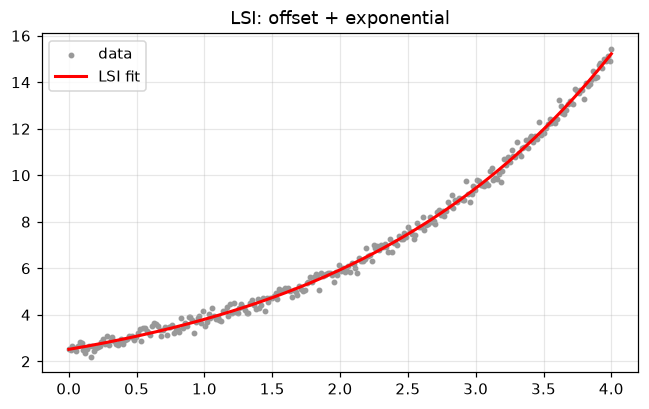

In [2]:
from dtfit import fit_lsi

x = np.linspace(0, 4, 300)
y = 0.5 + 2.0 * np.exp(0.5 * x) + rng.normal(0, 0.2, x.size)

res = fit_lsi(x, y, "a0 + a1*exp(a2*x)", "x", k_star=6)
print(res.summary())

plt.scatter(x, y, s=8, color="0.6", label="data")
plt.plot(x, res.predict(x), "r-", lw=2, label="LSI fit")
plt.legend(); plt.title("LSI: offset + exponential"); plt.show()

### The oscillatory recipe

A smoothed, low-order spectral fit *erases* cycles. For oscillatory models pass
`freq_param` (its initial guess is seeded from the data's FFT peak via
`fft_frequency_seed`) - this implies the oscillatory recipe (no smoothing, order
raised to resolve the cycle).

FFT frequency seed: 1.8802
recovered: {'A': 1.992, 'p': 0.505, 'w': 1.699}


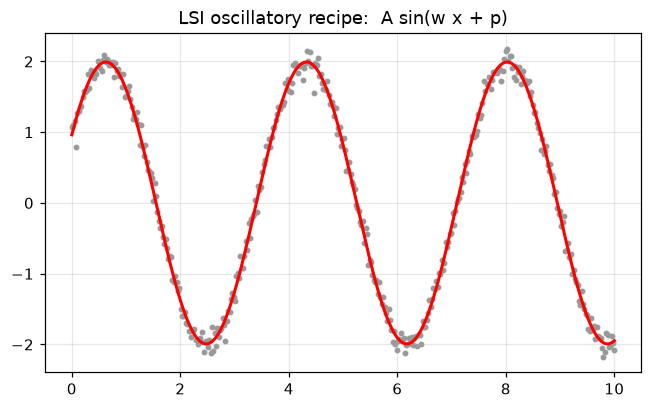

In [3]:
from dtfit import fft_frequency_seed

xs = np.linspace(0, 10, 400)
y = 2.0 * np.sin(1.7 * xs + 0.5) + rng.normal(0, 0.10, xs.size)

print("FFT frequency seed:", round(fft_frequency_seed(xs, y), 4))
res = fit_lsi(xs, y, "A*sin(w*x + p)", "x", freq_param="w")
print("recovered:", {k: round(v, 3) for k, v in res.params.items()})

plt.scatter(xs, y, s=8, color="0.6")
plt.plot(xs, res.predict(xs), "r-", lw=2)
plt.title("LSI oscillatory recipe:  A sin(w x + p)"); plt.show()

## EDA - `fit_eda` / `fit_eda_adaptive`

Equal-areas matches *integrals* over windows, so it naturally averages over
sparse outliers; the `loss="soft_l1"` option adds extra protection under heavier
contamination. The **adaptive** variant places window edges by curvature -
narrow where the signal bends, wide where it is smooth - which suits localized
transients and peaks.

truth    : {'a': 3.0, 'w': 1.5}
recovered: {'a': 2.85, 'w': 1.631}


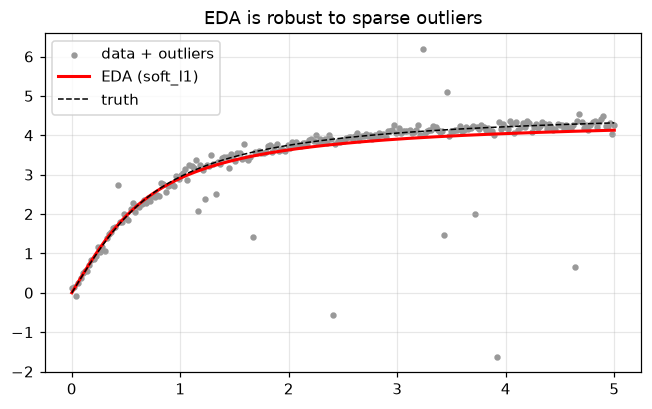

In [4]:
from dtfit import fit_eda

x = np.linspace(0, 5, 250)
y = 3.0 * np.arctan(1.5 * x) + rng.normal(0, 0.1, x.size)   # truth: a=3, w=1.5
y_out = y.copy()
idx = rng.choice(x.size, 12, replace=False)
y_out[idx] += rng.normal(0, 3.0, 12)                        # scattered outliers

res = fit_eda(x, y_out, "a*atan(w*x)", "x", loss="soft_l1")
print("truth    : {'a': 3.0, 'w': 1.5}")
print("recovered:", {k: round(v, 3) for k, v in res.params.items()})

plt.scatter(x, y_out, s=10, color="0.6", label="data + outliers")
plt.plot(x, res.predict(x), "r-", lw=2, label="EDA (soft_l1)")
plt.plot(x, 3.0 * np.arctan(1.5 * x), "k--", lw=1, label="truth")
plt.legend(); plt.title("EDA is robust to sparse outliers"); plt.show()

params: {'a': 4.998, 'b': 1.199}


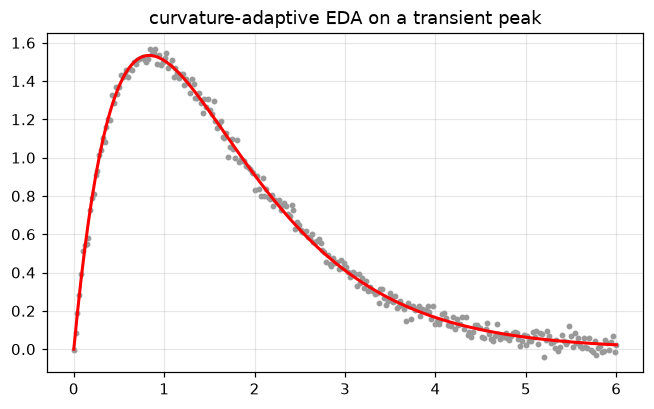

In [5]:
from dtfit import fit_eda_adaptive

x = np.linspace(0, 6, 300)
y = 5.0 * x * np.exp(-1.2 * x) + rng.normal(0, 0.03, x.size)   # rise-then-decay peak

res = fit_eda_adaptive(x, y, "a*x*exp(-b*x)", "x", window_mode="curvature")
print("params:", {k: round(v, 3) for k, v in res.params.items()})

plt.scatter(x, y, s=8, color="0.6")
plt.plot(x, res.predict(x), "r-", lw=2)
plt.title("curvature-adaptive EDA on a transient peak"); plt.show()

## DSB - `fit_dsb`

DSB equates the model's Maclaurin spectrum to a polynomial pre-fit's, order by
order. Build the **ascending** polynomial coefficients (the data's Taylor
spectrum) with `find_degree` + `np.polyfit`, then balance. (`NonlineRegressor`
with `method="dsb"` runs this pre-fit for you - notebook 04.)

polynomial degree: 4
FittingResult: a*exp(b*x)
  a = 1.4956 +/- 0.139
  b = 1.10634 +/- 0.0931


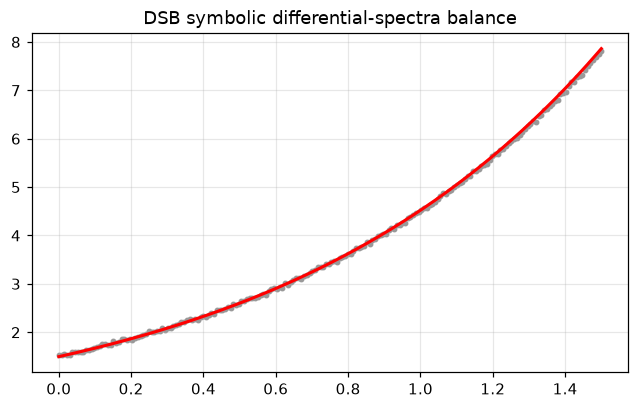

In [6]:
from dtfit import fit_dsb, find_degree

x = np.linspace(0, 1.5, 200)
y = 1.5 * np.exp(1.1 * x) + rng.normal(0, 0.02, x.size)    # truth: a=1.5, b=1.1

deg = find_degree(x, y)                  # BIC-selected polynomial degree
pc = np.polyfit(x, y, deg)[::-1]         # ascending coeffs = data Maclaurin spectrum
res = fit_dsb(pc, "a*exp(b*x)", "x")
print("polynomial degree:", deg)
print(res.summary())                     # recovers a~1.5, b~1.1

plt.scatter(x, y, s=8, color="0.6")
plt.plot(x, res.predict(x), "r-", lw=2)
plt.title("DSB symbolic differential-spectra balance"); plt.show()

## Comparing fits

`fit_report` turns any `FittingResult` into r^2 / RMSE / AIC / BIC (notebook 07).

In [7]:
from dtfit import fit_eda
from dtfit.diagnostics import fit_report

x = np.linspace(0, 3, 200)
y = 1.4 * np.exp(0.8 * x) + rng.normal(0, 0.15, x.size)
for name, r in [("LSI", fit_lsi(x, y, "a*exp(b*x)", "x")),
                ("EDA", fit_eda(x, y, "a*exp(b*x)", "x"))]:
    rep = fit_report(r, x, y)
    print(f"{name}:  r2={rep['r2']:.4f}   rmse={rep['rmse']:.4f}   aic={rep['aic']:.1f}")

LSI:  r2=0.9985   rmse=0.1513   aic=-751.4
EDA:  r2=0.9985   rmse=0.1515   aic=-750.9
